In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetRegressor

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Serif",
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'figure.dpi': 125
})

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

In [4]:
sig_df = pd.read_csv('data/Jewel.csv', header=None)
bg_df = pd.read_csv('data/Pythia.csv', header=None)
herwig_df = pd.read_csv('data/Herwig.csv', header=None)
hydrocolbt_df = pd.read_csv('data/CoLBTHydro.csv', header=None)

In [5]:
sig_df

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
0,42.0,35.868507,225.950089,8.0,0.178951,0.026906,0.172900,0.370362,29.600052,0.167371,...,0.0,0.653852,0.075139,0.097564,0.1,0.540970,0.109239,0.139838,0.2,1.0
1,58.0,48.554897,324.066040,10.0,0.005439,0.020294,0.011550,0.156185,104.071388,-0.074728,...,0.0,1.439689,-0.028542,0.205332,0.1,1.415878,0.360939,0.042718,0.1,1.0
2,56.0,26.970377,124.865440,9.0,0.231244,0.019723,0.037505,0.068383,14.950225,-0.042978,...,0.0,1.162606,0.173379,0.132102,0.2,1.131281,-0.096780,0.135162,0.0,1.0
3,44.0,27.604866,156.338135,11.0,0.017857,0.021562,0.007555,0.056032,19.271734,0.051588,...,0.3,0.735927,0.299181,0.058869,0.0,0.732596,0.353424,0.071139,0.0,1.0
4,19.0,18.787031,176.469116,7.0,0.006980,0.013870,0.002512,0.029962,27.828556,0.142101,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109812,49.0,49.566837,317.271423,7.0,0.396709,0.043922,0.798025,1.025950,45.624454,-0.174358,...,0.0,1.385516,0.022079,-0.060742,0.0,1.278958,-0.085583,-0.024182,0.2,1.0
109813,48.0,22.306828,126.216202,8.0,0.277971,0.045089,0.253107,0.449565,14.581024,0.030720,...,0.2,0.846151,0.009212,0.225702,0.0,0.784022,-0.184266,-0.000848,0.1,1.0
109814,29.0,21.221823,136.381439,7.0,0.441004,0.029211,0.468838,0.527827,20.344124,0.087500,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0
109815,26.0,26.304419,391.178833,5.0,0.330380,0.019840,0.502957,0.748650,51.380360,0.017224,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0


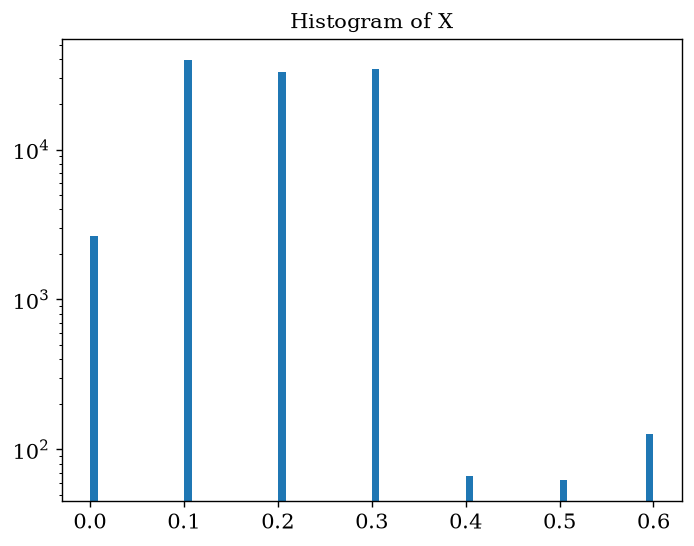

In [6]:
X = sig_df.iloc[:, 11:12].values
plt.hist(X, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram of X")
plt.yscale('log')
plt.show()

In [7]:
X

array([[0.2],
       [0.2],
       [0.1],
       ...,
       [0.1],
       [0.1],
       [0.3]])

In [8]:
sig_X = sig_df.dropna().iloc[:,0:-1].values
sig_Y = sig_df.dropna().iloc[:,-1].values

bg_X = bg_df.dropna().iloc[:,0:-1].values
bg_Y = bg_df.dropna().iloc[:,-1].values

herwig_X = herwig_df.dropna().iloc[:,0:-1].values
herwig_Y = herwig_df.dropna().iloc[:,-1].values

hydrocolbt_X = hydrocolbt_df.dropna().iloc[:,0:-1].values
hydrocolbt_Y = hydrocolbt_df.dropna().iloc[:,-1].values

In [9]:
sig_X

array([[ 4.20000000e+01,  3.58685074e+01,  2.25950089e+02, ...,
         1.09239355e-01,  1.39838189e-01,  2.00000000e-01],
       [ 5.80000000e+01,  4.85548973e+01,  3.24066040e+02, ...,
         3.60938728e-01,  4.27181907e-02,  1.00000000e-01],
       [ 5.60000000e+01,  2.69703770e+01,  1.24865440e+02, ...,
        -9.67796594e-02,  1.35161579e-01,  0.00000000e+00],
       ...,
       [ 2.90000000e+01,  2.12218227e+01,  1.36381439e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.60000000e+01,  2.63044186e+01,  3.91178833e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.70000000e+01,  3.23033409e+01,  4.06898895e+02, ...,
        -6.57932237e-02, -1.28293526e-04,  2.00000000e-01]])

In [10]:
sig_df

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
0,42.0,35.868507,225.950089,8.0,0.178951,0.026906,0.172900,0.370362,29.600052,0.167371,...,0.0,0.653852,0.075139,0.097564,0.1,0.540970,0.109239,0.139838,0.2,1.0
1,58.0,48.554897,324.066040,10.0,0.005439,0.020294,0.011550,0.156185,104.071388,-0.074728,...,0.0,1.439689,-0.028542,0.205332,0.1,1.415878,0.360939,0.042718,0.1,1.0
2,56.0,26.970377,124.865440,9.0,0.231244,0.019723,0.037505,0.068383,14.950225,-0.042978,...,0.0,1.162606,0.173379,0.132102,0.2,1.131281,-0.096780,0.135162,0.0,1.0
3,44.0,27.604866,156.338135,11.0,0.017857,0.021562,0.007555,0.056032,19.271734,0.051588,...,0.3,0.735927,0.299181,0.058869,0.0,0.732596,0.353424,0.071139,0.0,1.0
4,19.0,18.787031,176.469116,7.0,0.006980,0.013870,0.002512,0.029962,27.828556,0.142101,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109812,49.0,49.566837,317.271423,7.0,0.396709,0.043922,0.798025,1.025950,45.624454,-0.174358,...,0.0,1.385516,0.022079,-0.060742,0.0,1.278958,-0.085583,-0.024182,0.2,1.0
109813,48.0,22.306828,126.216202,8.0,0.277971,0.045089,0.253107,0.449565,14.581024,0.030720,...,0.2,0.846151,0.009212,0.225702,0.0,0.784022,-0.184266,-0.000848,0.1,1.0
109814,29.0,21.221823,136.381439,7.0,0.441004,0.029211,0.468838,0.527827,20.344124,0.087500,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0
109815,26.0,26.304419,391.178833,5.0,0.330380,0.019840,0.502957,0.748650,51.380360,0.017224,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.0


In [11]:
sig_X_train, sig_X_test, sig_Y_train, sig_Y_test = train_test_split(sig_X, sig_Y, train_size=0.9, shuffle=False)
bg_X_train, bg_X_test, bg_Y_train, bg_Y_test = train_test_split(bg_X, bg_Y, train_size=0.9, shuffle=False)
herwig_X_train, herwig_X_test, herwig_Y_train, herwig_Y_test = train_test_split(herwig_X, herwig_Y, train_size=0.9, shuffle=False)
hydrocolbt_X_train, hydrocolbt_X_test, hydrocolbt_Y_train, hydrocolbt_Y_test = train_test_split(hydrocolbt_X, hydrocolbt_Y, train_size=0.9, shuffle=False)

In [12]:
X_test = np.concatenate((sig_X_test, bg_X_test, herwig_X_test, hydrocolbt_X_test), axis=0)
Y_test = np.concatenate((sig_Y_test, bg_Y_test, herwig_Y_test, hydrocolbt_Y_test), axis=0)


In [13]:
model = TabNetRegressor()
model.load_model('model/model.zip')

/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [14]:
Y_pred = model.predict(X_test)

In [15]:
explain_matrixq, masksq = model.explain(sig_X_test)
explain_matrixu, masksu = model.explain(bg_X_test)

In [16]:
def explain(i):
    exp_matrix = explain_matrix[i]/explain_matrix[i].sum()
    exp = []
    for i in range(len(exp_matrix)):
        if exp_matrix[i]: exp.append(f"{features[i]}: {exp_matrix[i]}")
    return exp

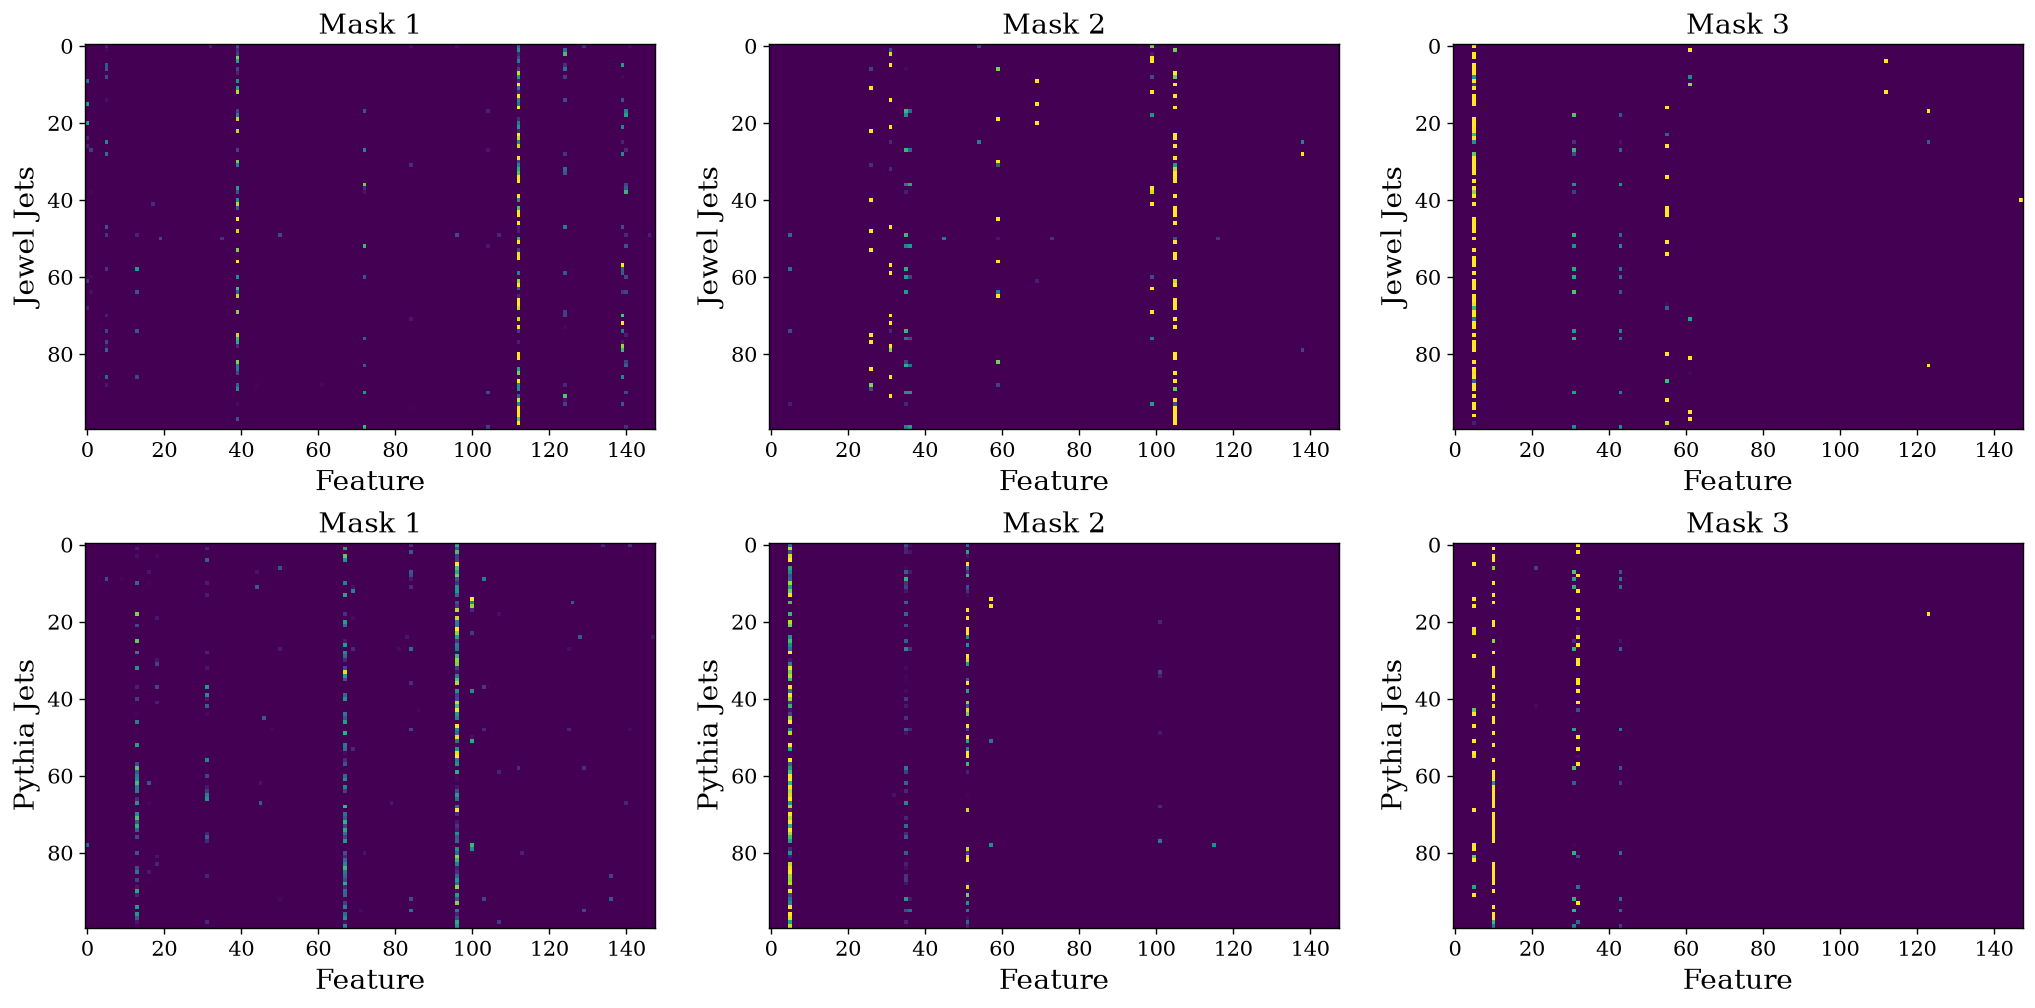

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(20,9.5))
for i in range(3):
    axs[0][i].imshow(masksq[i][:100])
    axs[0][i].set_title(f"Mask {i+1}", fontsize=16)
    axs[0][i].set_xlabel(f"Feature", fontsize=16)
    axs[0][i].set_ylabel(f"Jewel Jets", fontsize=16)
for i in range(3):
    axs[1][i].imshow(masksu[i][0:100])
    axs[1][i].set_title(f"Mask {i+1}", fontsize=16)
    axs[1][i].set_xlabel(f"Feature", fontsize=16)
    axs[1][i].set_ylabel(f"Pythia Jets", fontsize=16)
plt.savefig("featuremasks.pdf", bbox_inches='tight')

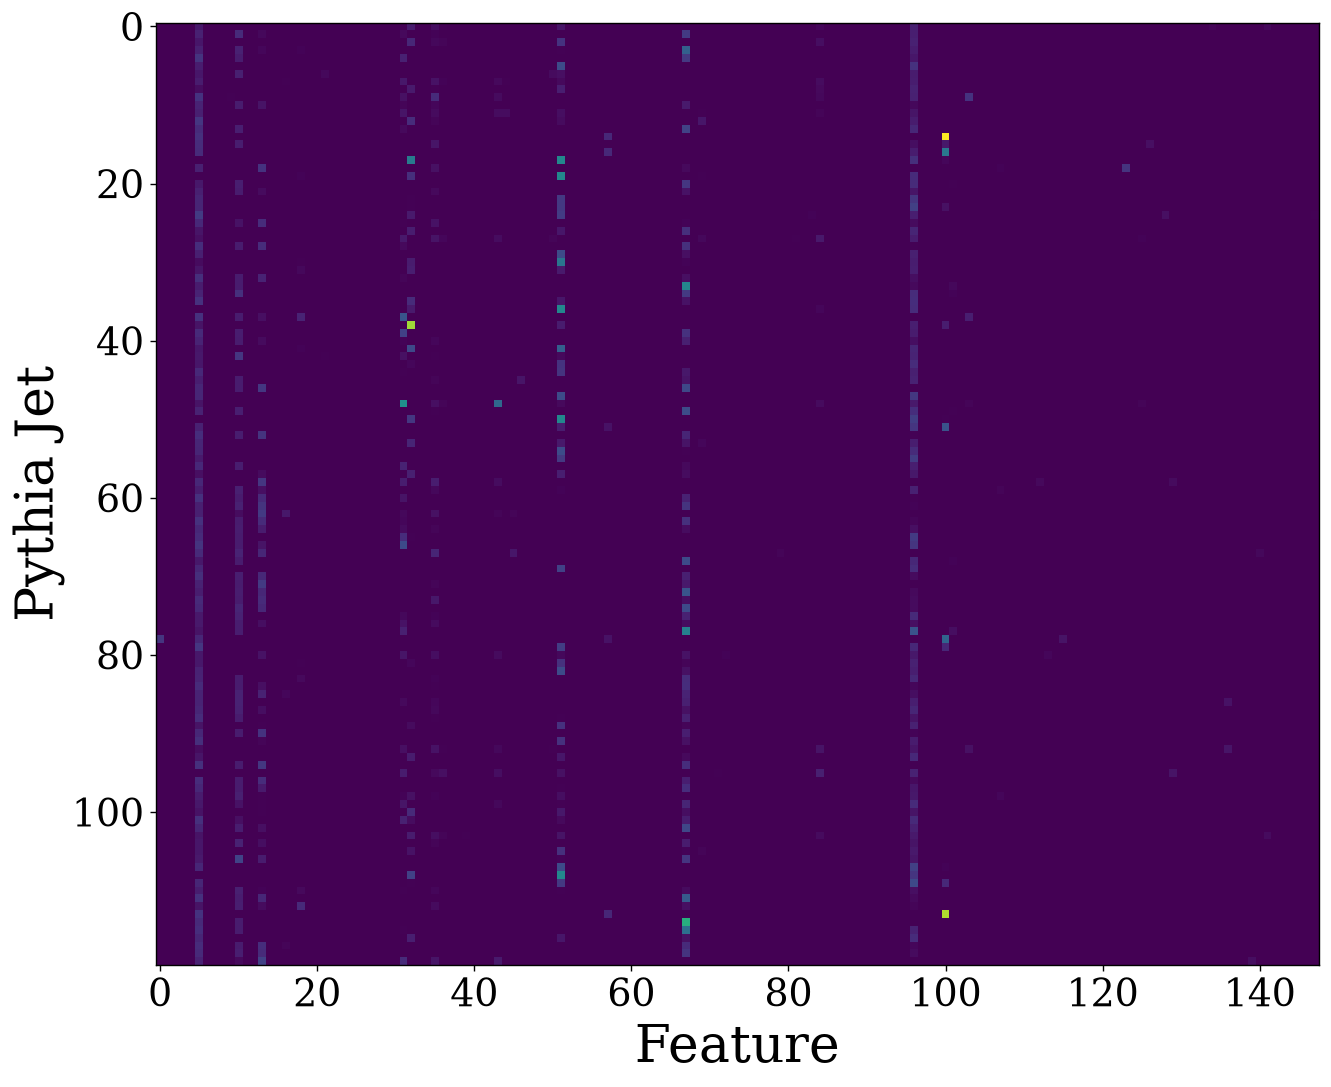

In [18]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax.imshow(explain_matrixu[0:120])
ax.set_xlabel(f"Feature", fontsize=30)
ax.set_ylabel(f"Pythia Jet", fontsize=30)
plt.savefig("explainmatrixpythia.pdf", bbox_inches='tight')
plt.show()

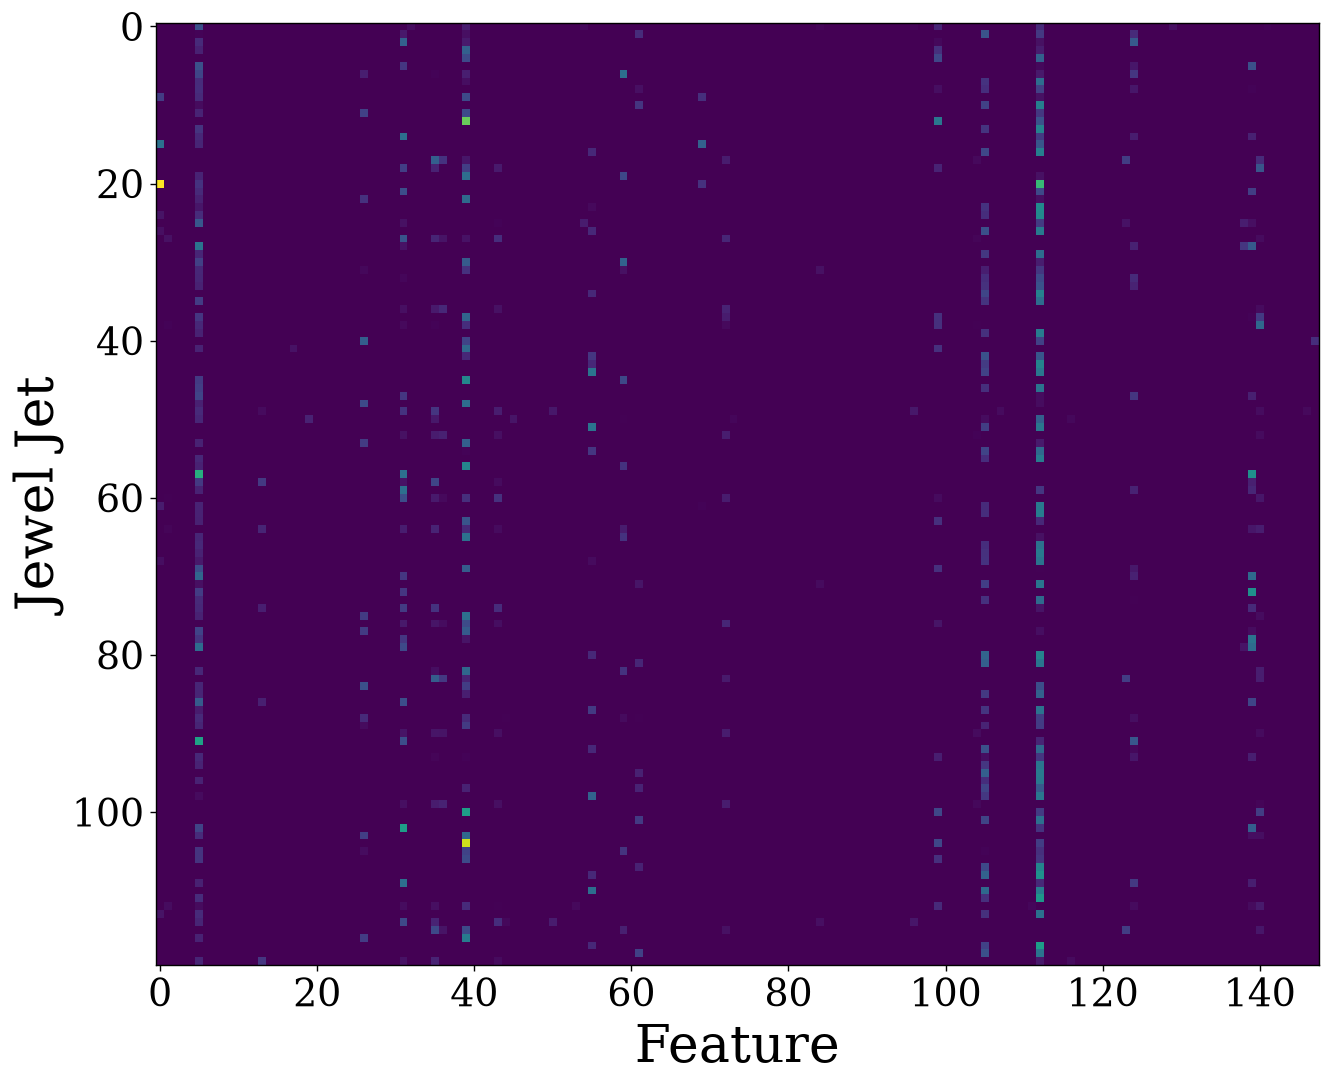

In [19]:
fig, ax = plt.subplots(1, figsize=(12,11))
ax.imshow(explain_matrixq[0:120])
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax.set_xlabel(f"Feature", fontsize=30)
ax.set_ylabel(f"Jewel Jet", fontsize=30)
plt.savefig("explainmatrixjewel.pdf", bbox_inches='tight')
plt.show()

In [20]:
SIG_out = model.predict(sig_X_test)
BG_out = model.predict(bg_X_test)
herwig_out = model.predict(herwig_X_test)
hydrocolbt_out = model.predict(hydrocolbt_X_test)

jewellowquench = np.where(SIG_out < 0.4)
jewelhighquench = np.where(SIG_out > 0.8)

jewel_low_quench_jetm = []
for i in jewellowquench[0]:
  jewel_low_quench_jetm.append(sig_X_test[i][1])
jewel_low_quench_jetm = np.array(jewel_low_quench_jetm)
jewel_low_quench_jetm = jewel_low_quench_jetm[jewel_low_quench_jetm != 0]

jewel_high_quench_jetm = []
for i in jewelhighquench[0]:
  jewel_high_quench_jetm.append(sig_X_test[i][1])
jewel_high_quench_jetm = np.array(jewel_high_quench_jetm)
jewel_high_quench_jetm = jewel_high_quench_jetm[jewel_high_quench_jetm != 0]

bins = np.linspace(0, 100, 25)

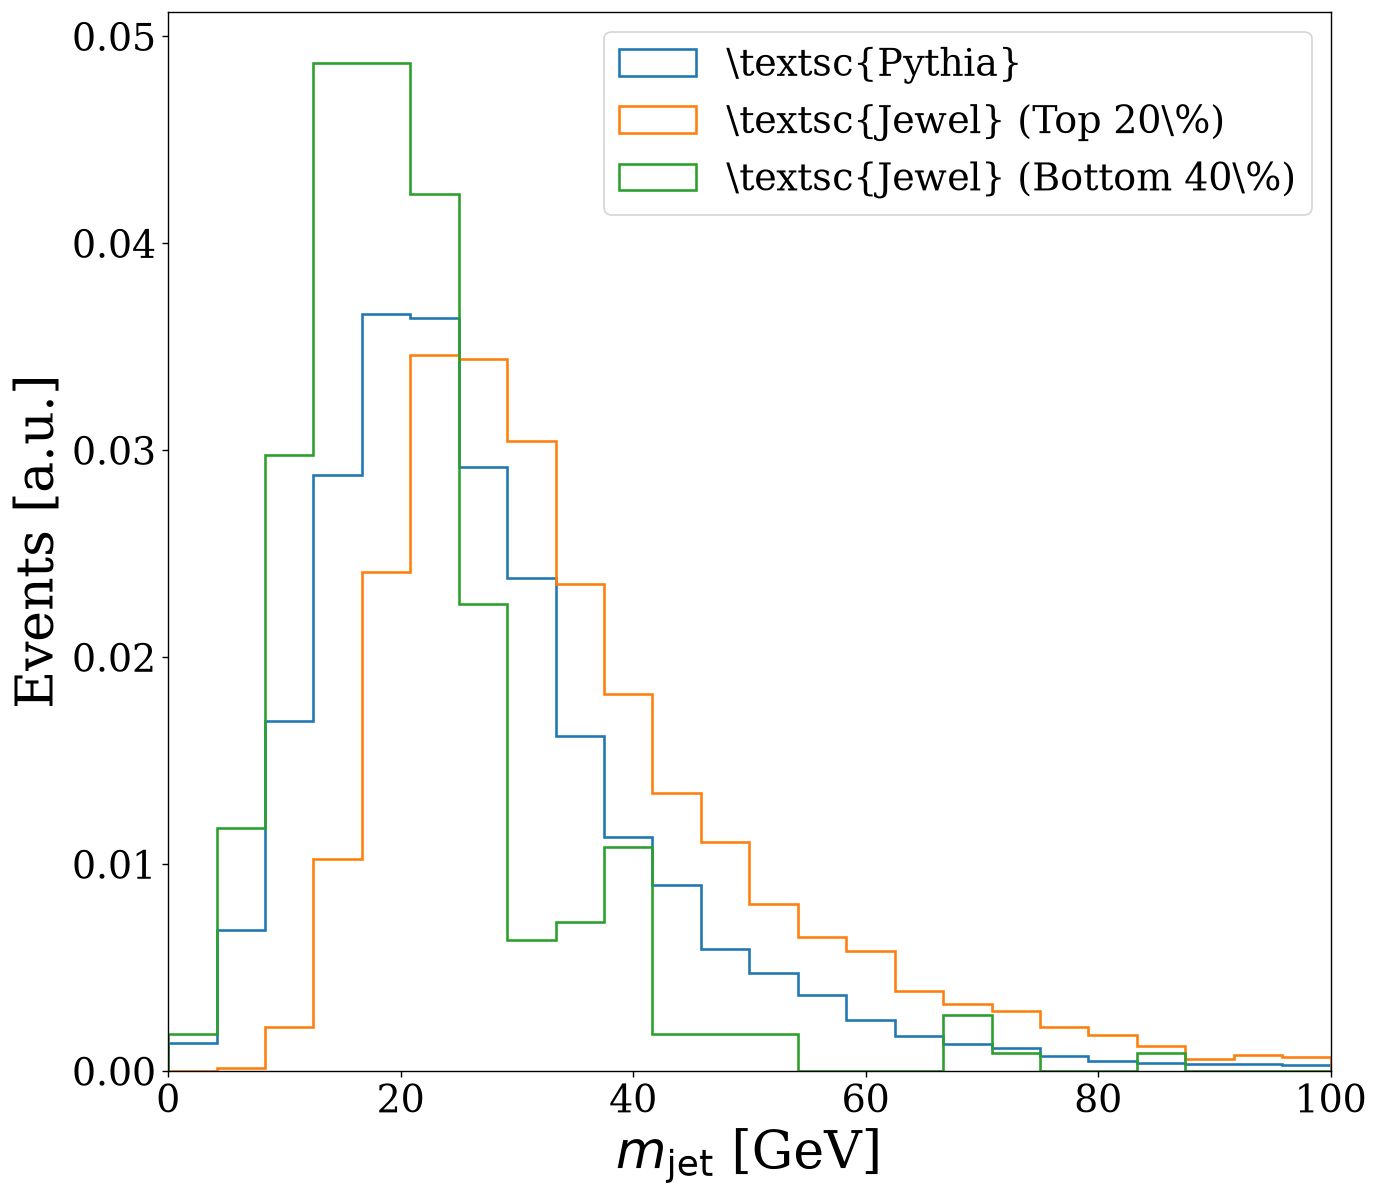

In [21]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(bg_X_test[:,1], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Pythia}")
plt.hist(jewel_high_quench_jetm, bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel} (Top 20\%)")
plt.hist(jewel_low_quench_jetm, bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel} (Bottom 40\%)")
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax.set_xlabel("$m_{\mathrm{jet}}$ [GeV]", fontsize=30)
# ax.set_ylabel(r"$\frac{1}{N}\frac{\mathrm{d}N}{\mathrm{d}{m}_{\mathrm{jet}}}$", fontsize=30)
ax.set_ylabel(r"Events [a.u.]", fontsize=30)
plt.legend(loc='upper right', fontsize=22)
plt.xlim(0,100)
plt.savefig('jetmassdistjewel.pdf', bbox_inches='tight')
plt.show()

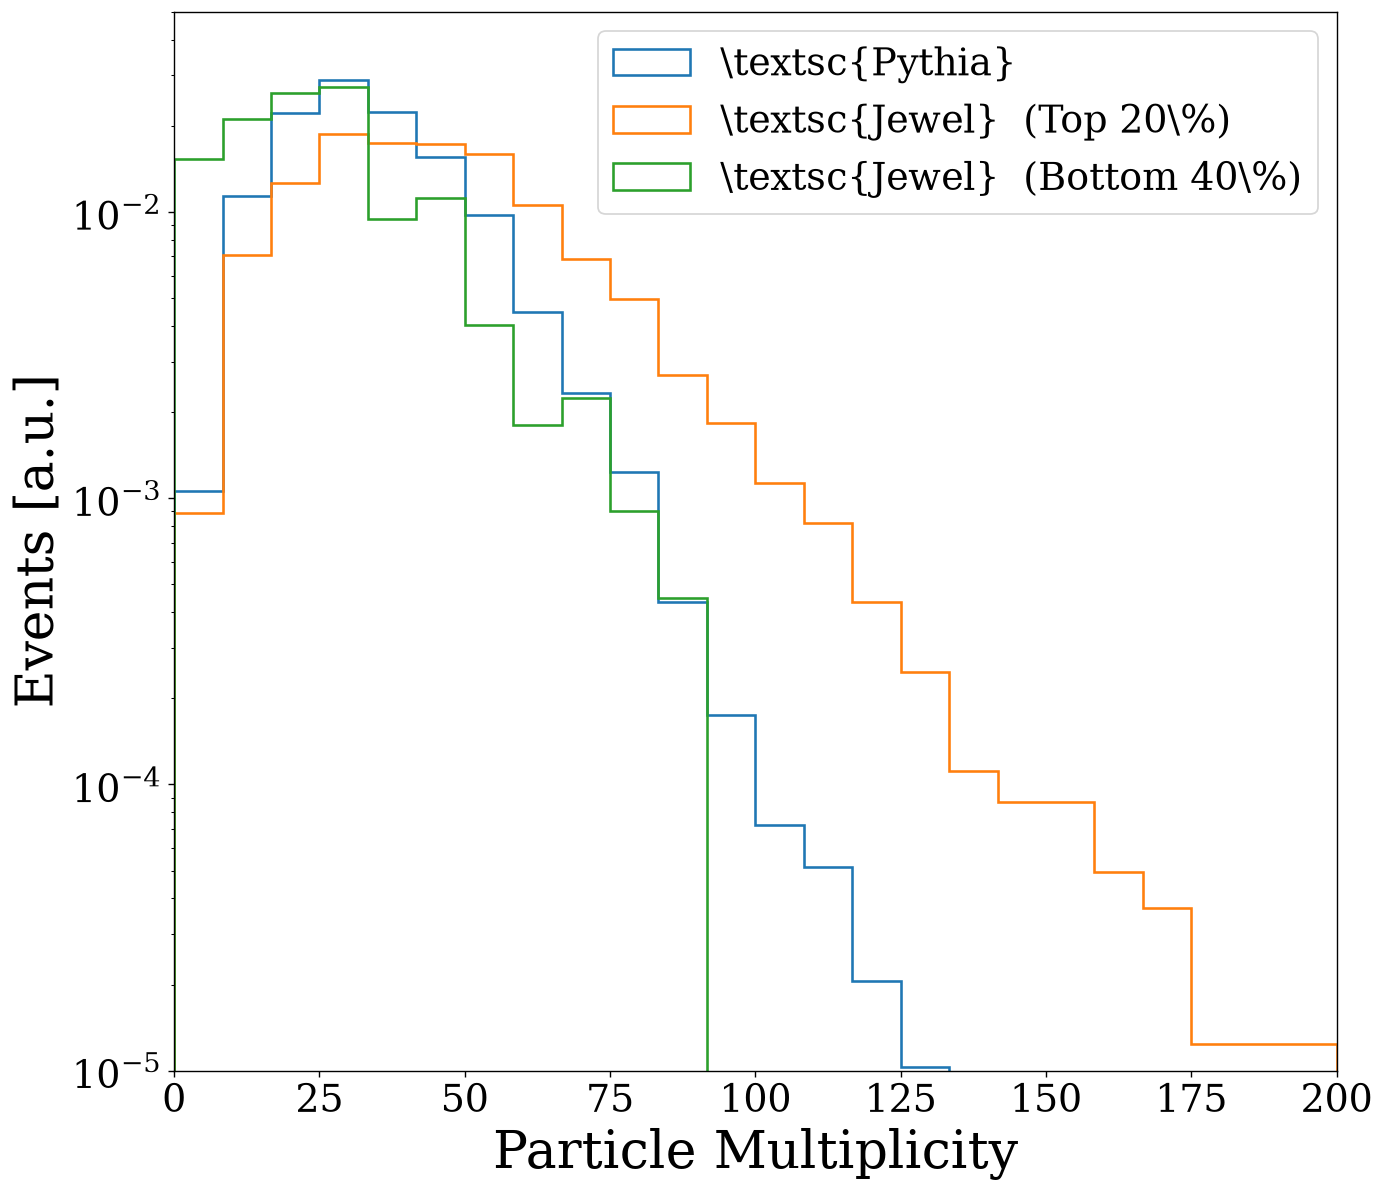

In [22]:
jewel_low_quench_mult = []
for i in jewellowquench[0]:
  jewel_low_quench_mult.append(sig_X_test[i][0])
jewel_low_quench_mult = np.array(jewel_low_quench_mult)

jewel_high_quench_mult = []
for i in jewelhighquench[0]:
  jewel_high_quench_mult.append(sig_X_test[i][0])
jewel_high_quench_mult = np.array(jewel_high_quench_mult)

bins = np.linspace(0, 200, 25)

fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(bg_X_test[:,0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Pythia}")
plt.hist(jewel_high_quench_mult, bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Top 20\%)")
plt.hist(jewel_low_quench_mult, bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Bottom 40\%)")
ax.set_xlabel("Particle Multiplicity", fontsize=30)
ax.set_ylabel(r"Events [a.u.]", fontsize=30)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(loc='upper right', fontsize=22)
plt.xlim(0, 200)
plt.ylim(1e-5, 0.05)
plt.yscale('log')
plt.savefig('jetmultdistjewel.pdf', bbox_inches='tight')
plt.show()

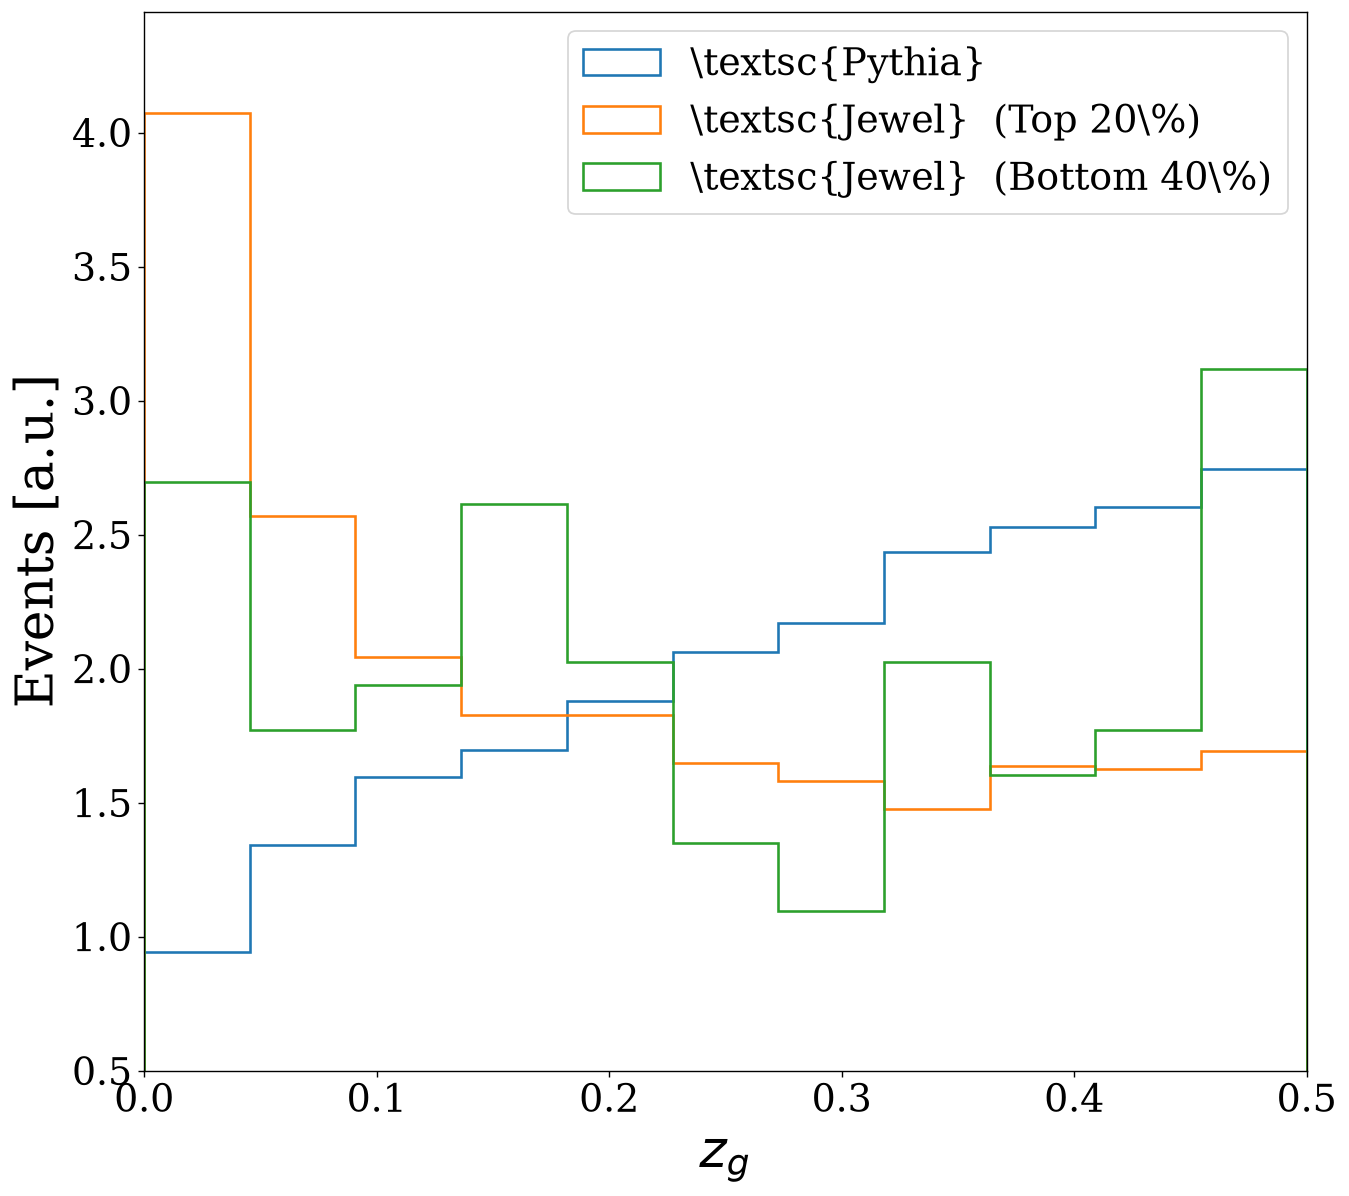

In [23]:
jewel_low_quench_zg = []
for i in jewellowquench[0]:
  jewel_low_quench_zg.append(sig_X_test[i][4])
jewel_low_quench_zg = np.array(jewel_low_quench_zg)

jewel_high_quench_zg = []
for i in jewelhighquench[0]:
  jewel_high_quench_zg.append(sig_X_test[i][4])
jewel_high_quench_zg = np.array(jewel_high_quench_zg)

bins = np.linspace(0, 0.5,12)

fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(bg_X_test[:,4][bg_X_test[:,4] != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Pythia}")
plt.hist(jewel_high_quench_zg[jewel_high_quench_zg != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Top 20\%)")
plt.hist(jewel_low_quench_zg[jewel_low_quench_zg != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Bottom 40\%)")
ax.set_xlabel("$z_g$", fontsize=30)
ax.set_ylabel(r"Events [a.u.]", fontsize=30)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(loc='upper right', fontsize=22)
plt.xlim(0, 0.5)
plt.ylim(0.5, 4.45)
# plt.yscale('log')
plt.savefig('jetzgdistjewel.pdf', bbox_inches='tight')
plt.show()

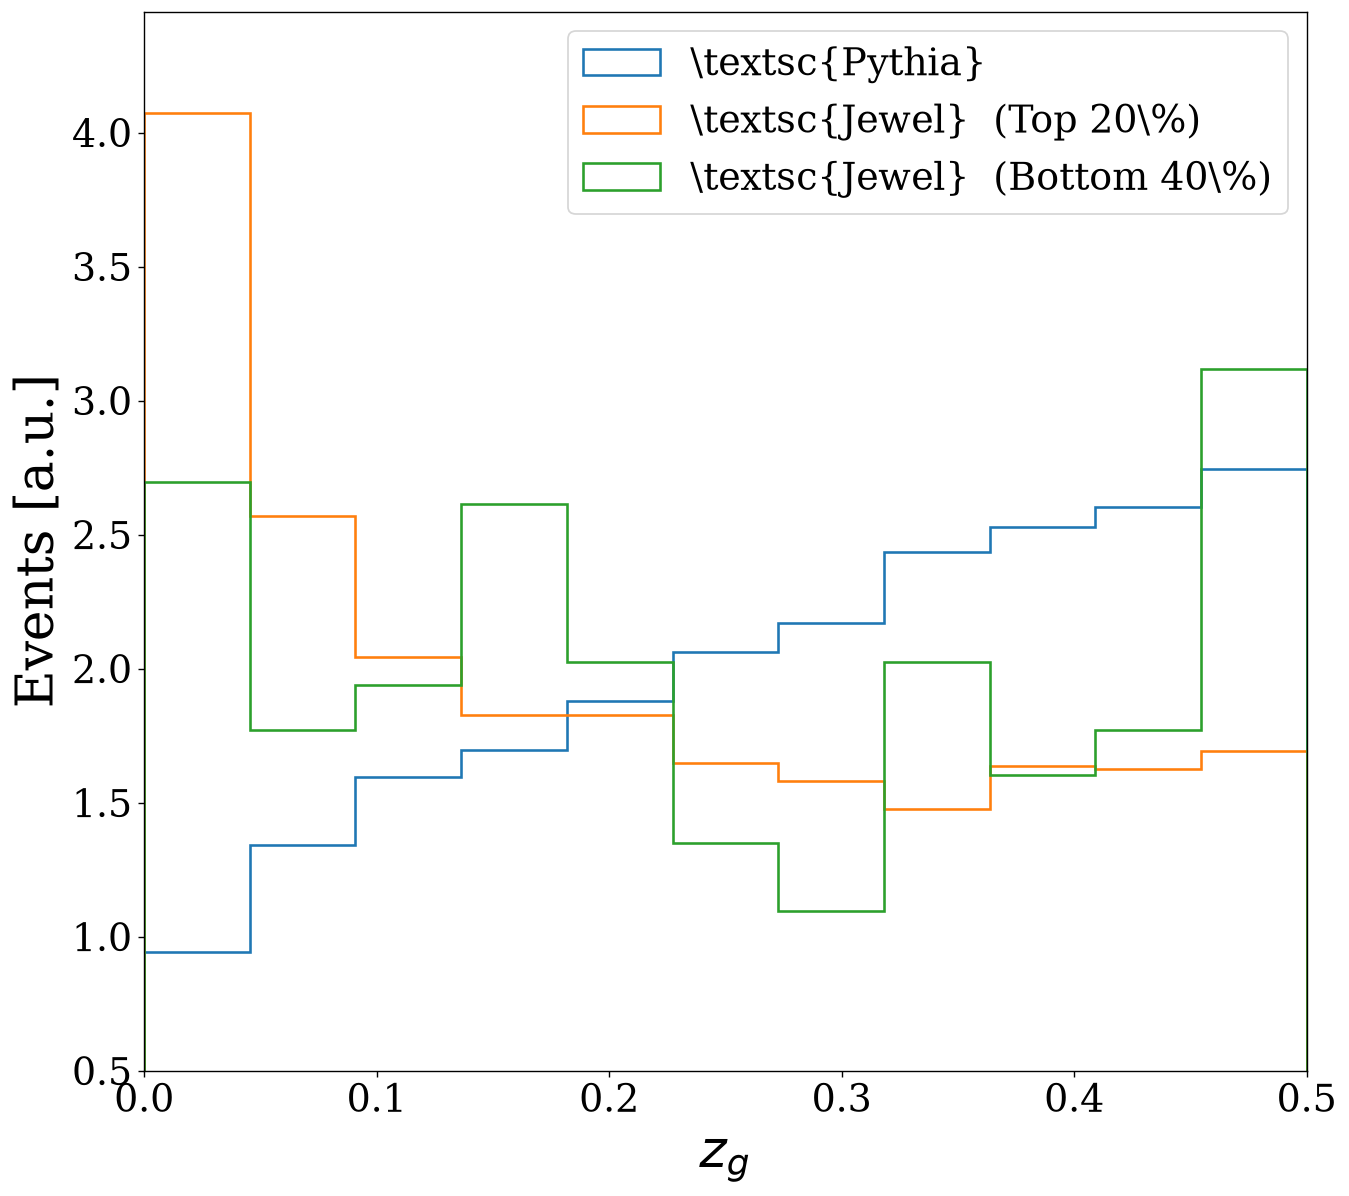

In [24]:
jewel_low_quench_zg = []
for i in jewellowquench[0]:
  jewel_low_quench_zg.append(sig_X_test[i][4])
jewel_low_quench_zg = np.array(jewel_low_quench_zg)

jewel_high_quench_zg = []
for i in jewelhighquench[0]:
  jewel_high_quench_zg.append(sig_X_test[i][4])
jewel_high_quench_zg = np.array(jewel_high_quench_zg)

bins = np.linspace(0, 0.5,12)

fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(bg_X_test[:,4][bg_X_test[:,4] != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Pythia}")
plt.hist(jewel_high_quench_zg[jewel_high_quench_zg != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Top 20\%)")
plt.hist(jewel_low_quench_zg[jewel_low_quench_zg != 0], bins, density=True, fill=False, histtype='step', linewidth=1.5, label="\\textsc{Jewel}  (Bottom 40\%)")
ax.set_xlabel("$z_g$", fontsize=30)
ax.set_ylabel(r"Events [a.u.]", fontsize=30)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(loc='upper right', fontsize=22)
plt.xlim(0, 0.5)
plt.ylim(0.5, 4.45)
# plt.yscale('log')
plt.savefig('jetzgdistjewel.pdf', bbox_inches='tight')
plt.show()